In [63]:
import numpy as np

# Load the data from the specified file
data = np.load('data/loc_test_springs5_dynamic3.npy')
data = data[:, :49]
print(f"Loaded data with shape: {data.shape}")


Loaded data with shape: (10000, 49, 2, 5)


In [81]:
import torch

edges = np.load("data/edges_test_springs5_dynamic3.npy")
edges = torch.tensor(edges[:, :49]).reshape(-1, 49, 25)
print(f"Loaded edges with shape: {edges.shape}")

change_point_count = ((torch.diff(edges, dim=1) != 0).sum(dim=-1) != 0).sum(dim=-1).numpy()

Loaded edges with shape: torch.Size([10000, 49, 25])


In [82]:
change_point_count.shape

(10000,)

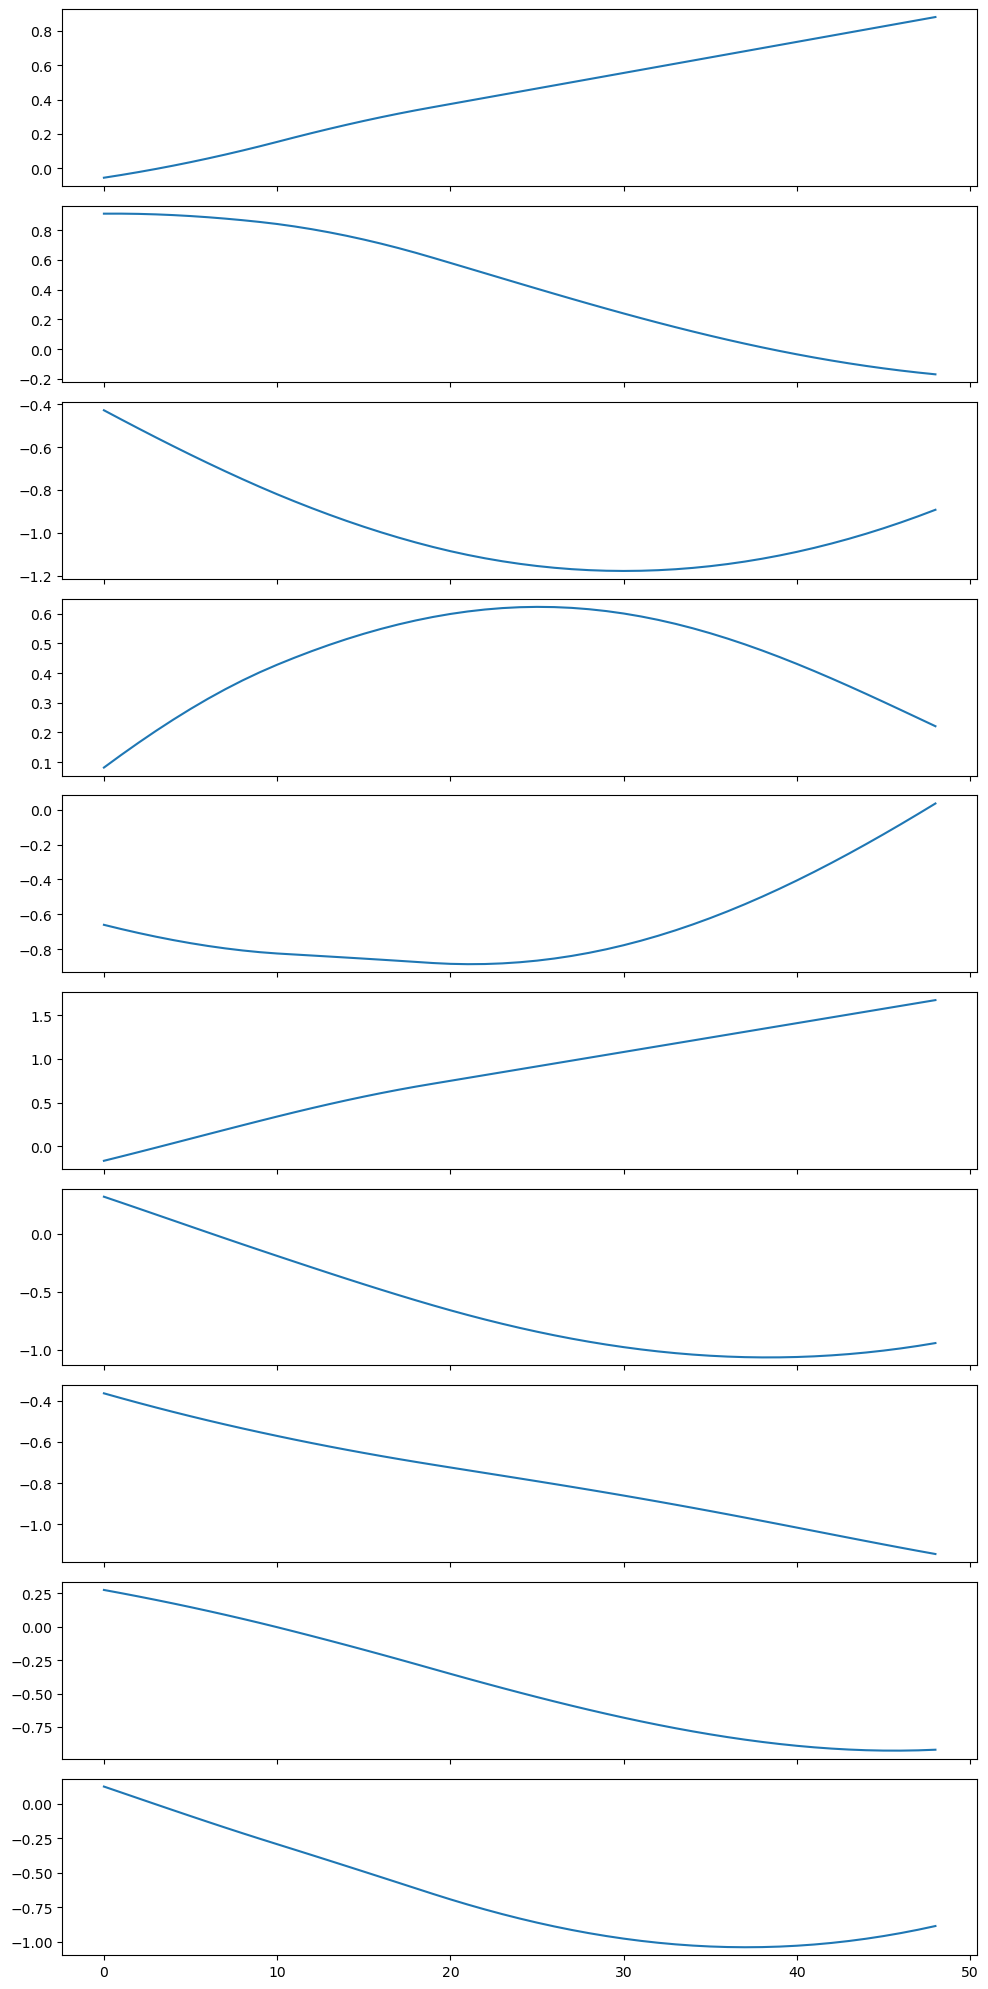

In [124]:
import matplotlib.pyplot as plt
import ruptures as rpt
import pandas as pd
import numpy as np

lens0 = []
lens1 = []
lens2 = []
lens3 = []
for i in range(10):
    signal = data[i].reshape(-1, 10)

    
    # Calculate velocities (differences between consecutive positions)
    velocities = np.diff(signal, axis=0)
    # Add a zero row at the beginning to maintain the same shape
    velocities = np.vstack([np.zeros((1, signal.shape[1])), velocities])
    
    # Apply exponential moving average to smooth the velocities
    # Convert to pandas DataFrame for easy EMA calculationa
    velocities_df = pd.DataFrame(velocities)
    smoothed_velocities = velocities_df.ewm(span=16).mean()
    
    # Calculate the difference between original and smoothed velocities
    # Large differences indicate potential change points
    diff_signal = np.abs(velocities - smoothed_velocities)
    
    # Sum across dimensions to get a univariate signal of changes
    #change_indicator = np.sum(diff_signal, axis=1)

    # Use Pelt algorithm which is good for detecting abrupt changes
    # in otherwise smooth signals
    algo = rpt.Window(model="rbf").fit(diff_signal)
    result = algo.predict(pen=2)  # Penalty parameter controls sensitivity
    
    if change_point_count[i] == 0:
        lens0.append(len(result) - 1)
    elif change_point_count[i] == 1:
        lens1.append(len(result) - 1)
    elif change_point_count[i] == 2:
        lens2.append(len(result) - 1)
    elif change_point_count[i] == 3:
        lens3.append(len(result) - 1)

# Create bar plots instead of histograms

# For lens0
if False:
    unique_values0, counts0 = np.unique(lens0, return_counts=True)
    plt.bar(unique_values0, counts0)
    plt.xlabel('Number of Change Points')
    plt.ylabel('Count')
    plt.title('Distribution for True Change Points = 0')
    plt.show()

    # For lens1
    unique_values1, counts1 = np.unique(lens1, return_counts=True)
    plt.bar(unique_values1, counts1)
    plt.xlabel('Number of Change Points')
    plt.ylabel('Count')
    plt.title('Distribution for True Change Points = 1')
    plt.show()

    # For lens2
    unique_values2, counts2 = np.unique(lens2, return_counts=True)
    plt.bar(unique_values2, counts2)
    plt.xlabel('Number of Change Points')
    plt.ylabel('Count')
    plt.title('Distribution for True Change Points = 2')
    plt.show()

    # For lens3
    unique_values3, counts3 = np.unique(lens3, return_counts=True)
    plt.bar(unique_values3, counts3)
    plt.xlabel('Number of Change Points')
    plt.ylabel('Count')
    plt.title('Distribution for True Change Points = 3')
    plt.show()

# display
rpt.display(data[16].reshape(-1, 10), [], result)
plt.show()

In [109]:
data[0].reshape(-1, 10).shape

(49, 10)